# NLP Processing With spaCy

SpaCy is a Python software library for automatic processing of many languages. It is an essential toolbox for the computational analysis of text corpora.

This course is an introduction to its main features, including:

- tokenization
- lemmatization
- named-Entities recognition and linking

Some reading material:

- https://spacy.io/
- Avanced NLP with Spacy : https://course.spacy.io/en/
- https://github.com/mchesterkadwell/named-entity-recognition/blob/main/1-basic-text-mining-concepts.ipynb
- for NER : https://melaniewalsh.github.io/Intro-Cultural-Analytics/05-Text-Analysis/12-Named-Entity-Recognition.html
- for Text-Mining (basics) : https://github.com/mchesterkadwell/named-entity-recognition/blob/main/1-basic-text-mining-concepts.ipynb 

This course includes parts of the excellent tutorial "Natural Language Processing With spaCy in Python": 
https://realpython.com/natural-language-processing-spacy-python

In [1]:
# Install and import Spacy
# !pip install -U spacy

In [2]:
import spacy

## Language Processing Pipelines & Trained Models

[https://spacy.io/usage/processing-pipelines](https://spacy.io/usage/processing-pipelines)

When you call nlp on a text, spaCy first tokenizes the text to produce a [Doc object](https://spacy.io/api/doc). The Doc is then processed in several different steps (ie the processing pipeline). Each pipeline component returns the processed Doc, which is then passed on to the next component.

![spacy_pipeline](../img/spacy_pipeline.svg)

The capabilities of a processing pipeline always depend on the components, their models and how they were trained. For example, a pipeline for named entity recognition needs to include a trained named entity recognizer component.

Reference should be made to the documentation of the models made available : [https://spacy.io/models](https://spacy.io/models)



**Models available for French:**

|name|genre|size|use|components|
|----|-----|----|---|----------|
|[fr_core_news_sm](https://spacy.io/models/fr#fr_core_news_sm)|written text (news, media)|15 MB|CPU|tok2vec, morphologizer, parser, senter, attribute_ruler, lemmatizer, ner|
|[fr_core_news_md](https://spacy.io/models/fr#fr_core_news_md)|written text (news, media)|43 MB|CPU|tok2vec, morphologizer, parser, senter, ner, attribute_ruler, lemmatizer|
|[fr_core_news_lg](https://spacy.io/models/fr#fr_core_news_lg)|written text (news, media)|545 MN|CPU|tok2vec, morphologizer, parser, senter, ner, attribute_ruler, lemmatizer|
|[fr_dep_news_trf](https://spacy.io/models/fr#fr_dep_news_trf)|written text (news, media)|382 MB|GPU (camembert-base)|transformer, morphologizer, parser, attribute_ruler, lemmatizer|

## Install and import trained pipeline

In [3]:
!python -m spacy download fr_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 5.9 MB/s eta 0:00:00m eta 0:00:010:00:01

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')


The load() function returns a [Language callable object](https://spacy.io/api/language), which is commonly assigned to a variable called nlp.

In [4]:
import fr_core_news_md
nlp = fr_core_news_md.load()

In [5]:
type(nlp)

spacy.lang.fr.French

In [6]:
print(nlp.pipe_names)

['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Tokens

To start processing your input, you construct a [Doc object](https://spacy.io/api/doc). 

A Doc object is a sequence of [Token](https://spacy.io/api/token) objects representing a lexical token (~ a word). each token contains different features describing it (lemma, morpho-syntactic label, etc.).

**You can instantiate a Doc object by calling the Language object with the input string as an argument**:

In [7]:
quote = 'Quant aux gens que j’accuse, je ne les connais pas, je ne les ai jamais vus, je n’ai contre eux ni rancune ni haine. Ils ne sont pour moi que des entités, des esprits de malfaisance sociale. Et l’acte que j’accomplis ici n’est qu’un moyen révolutionnaire pour hâter l’explosion de la vérité et de la justice.\nJe n’ai qu’une passion, celle de la lumière, au nom de l’humanité qui a tant souffert et qui a droit au bonheur. Ma protestation enflammée n’est que le cri de mon âme. Qu’on ose donc me traduire en cour d’assises et que l’enquête ait lieu au grand jour !\nJ’attends.'
document = nlp(quote)

Chaque token a de nombreux [attributs](https://spacy.io/api/token#attributes) facilement accessibles.

In [8]:
document_tokens = []
for token in document:
    document_tokens.append(token.text)
print(document_tokens)

['Quant', 'aux', 'gens', 'que', 'j’', 'accuse', ',', 'je', 'ne', 'les', 'connais', 'pas', ',', 'je', 'ne', 'les', 'ai', 'jamais', 'vus', ',', 'je', 'n’', 'ai', 'contre', 'eux', 'ni', 'rancune', 'ni', 'haine', '.', 'Ils', 'ne', 'sont', 'pour', 'moi', 'que', 'des', 'entités', ',', 'des', 'esprits', 'de', 'malfaisance', 'sociale', '.', 'Et', 'l’', 'acte', 'que', 'j’', 'accomplis', 'ici', 'n’', 'est', 'qu’', 'un', 'moyen', 'révolutionnaire', 'pour', 'hâter', 'l’', 'explosion', 'de', 'la', 'vérité', 'et', 'de', 'la', 'justice', '.', '\n', 'Je', 'n’', 'ai', 'qu’', 'une', 'passion', ',', 'celle', 'de', 'la', 'lumière', ',', 'au', 'nom', 'de', 'l’', 'humanité', 'qui', 'a', 'tant', 'souffert', 'et', 'qui', 'a', 'droit', 'au', 'bonheur', '.', 'Ma', 'protestation', 'enflammée', 'n’', 'est', 'que', 'le', 'cri', 'de', 'mon', 'âme', '.', 'Qu’', 'on', 'ose', 'donc', 'me', 'traduire', 'en', 'cour', 'd’', 'assises', 'et', 'que', 'l’', 'enquête', 'ait', 'lieu', 'au', 'grand', 'jour', '!', '\n', 'J’', 'a

Or, more simply, by using a [List comprehension](https://www.w3schools.com/python/python_lists_comprehension.asp):

In [9]:
[token.text for token in document]

['Quant',
 'aux',
 'gens',
 'que',
 'j’',
 'accuse',
 ',',
 'je',
 'ne',
 'les',
 'connais',
 'pas',
 ',',
 'je',
 'ne',
 'les',
 'ai',
 'jamais',
 'vus',
 ',',
 'je',
 'n’',
 'ai',
 'contre',
 'eux',
 'ni',
 'rancune',
 'ni',
 'haine',
 '.',
 'Ils',
 'ne',
 'sont',
 'pour',
 'moi',
 'que',
 'des',
 'entités',
 ',',
 'des',
 'esprits',
 'de',
 'malfaisance',
 'sociale',
 '.',
 'Et',
 'l’',
 'acte',
 'que',
 'j’',
 'accomplis',
 'ici',
 'n’',
 'est',
 'qu’',
 'un',
 'moyen',
 'révolutionnaire',
 'pour',
 'hâter',
 'l’',
 'explosion',
 'de',
 'la',
 'vérité',
 'et',
 'de',
 'la',
 'justice',
 '.',
 '\n',
 'Je',
 'n’',
 'ai',
 'qu’',
 'une',
 'passion',
 ',',
 'celle',
 'de',
 'la',
 'lumière',
 ',',
 'au',
 'nom',
 'de',
 'l’',
 'humanité',
 'qui',
 'a',
 'tant',
 'souffert',
 'et',
 'qui',
 'a',
 'droit',
 'au',
 'bonheur',
 '.',
 'Ma',
 'protestation',
 'enflammée',
 'n’',
 'est',
 'que',
 'le',
 'cri',
 'de',
 'mon',
 'âme',
 '.',
 'Qu’',
 'on',
 'ose',
 'donc',
 'me',
 'traduire',
 '

In [10]:
'''
for token in document:
    print(token.text, token.lemma_, token.pos_, token.is_punct, token.is_stop, token.sent[:4])
'''
print(
    f"{'Index':9}"
    f"{'Text':15}"
    f"{'Lemma':15}"
    f"{'POS':10}"
    f"{'Punct?':10}"
    f"{'Stop Word?':15}"
    f"{'Sentence beginning'}"
)
for token in document[71:92]:
    print(
        f"{str(token.i):9}"
        f"{str(token.text):15}"
        f"{str(token.lemma_):15}"
        f"{str(token.pos_):10}"
        f"{str(token.is_punct):10}"
        f"{str(token.is_stop):15}"
        f"{str(token.sent[:6])+'…'}"
    )


Index    Text           Lemma          POS       Punct?    Stop Word?     Sentence beginning
71       Je             je             PRON      False     True           Et l’acte que j’accomplis…
72       n’             n’             ADV       False     True           Et l’acte que j’accomplis…
73       ai             avoir          VERB      False     True           Et l’acte que j’accomplis…
74       qu’            qu’            ADV       False     True           Et l’acte que j’accomplis…
75       une            un             DET       False     True           Et l’acte que j’accomplis…
76       passion        passion        NOUN      False     False          Et l’acte que j’accomplis…
77       ,              ,              PUNCT     True      False          Et l’acte que j’accomplis…
78       celle          celui          PRON      False     True           Et l’acte que j’accomplis…
79       de             de             ADP       False     True           Et l’acte que j’accomplis

You may need to store each token and its attributes in a dataframe:

In [11]:
# method 2: features 2 df
import pandas as pd
token_atts = []
for token in document:
    token_atts.append(
        [token.text, token.lemma_, token.pos_, token.is_punct, token.is_stop, f"{str(token.sent[:6])+'…'}"]
    )
token_atts_df = pd.DataFrame(token_atts)
token_atts_df.columns = ['Text', 'Lemma', 'POS', 'Is_Punct', 'Is_Stop_Word', 'Sentence_Begin']
token_atts_df.iloc[71:92]


,Text,Lemma,POS,Is_Punct,Is_Stop_Word,Sentence_Begin
71,Je,je,PRON,False,True,Et l’acte que j’accomplis…
72,n’,n’,ADV,False,True,Et l’acte que j’accomplis…
73,ai,avoir,VERB,False,True,Et l’acte que j’accomplis…
74,qu’,qu’,ADV,False,True,Et l’acte que j’accomplis…
75,une,un,DET,False,True,Et l’acte que j’accomplis…
76,passion,passion,NOUN,False,False,Et l’acte que j’accomplis…
77,",",",",PUNCT,True,False,Et l’acte que j’accomplis…
78,celle,celui,PRON,False,True,Et l’acte que j’accomplis…
79,de,de,ADP,False,True,Et l’acte que j’accomplis…
80,la,le,DET,False,True,Et l’acte que j’accomplis…


You can customize the tokenizer by defining your own segmentation rules:

- https://spacy.io/usage/linguistic-features#native-tokenizers
- https://realpython.com/natural-language-processing-spacy-python/#tokens-in-spacy

More often than not, we need to load the textual content of a file to instantiate a Doc object.  
The [pathlib](https://docs.python.org/3/library/pathlib.html) module offers classes representing filesystem paths with semantics appropriate for different operating systems.

Let's try, to load Zola's famous text:

In [12]:
import pathlib

file_path = '../data/zola_accuse_fr.txt'
zola_doc = nlp(pathlib.Path(file_path).read_text(encoding="utf-8"))
print([token.text for token in zola_doc])

['Monsieur', 'le', 'Président', ',', '\n', 'Me', 'permettez', '-vous', ',', 'dans', 'ma', 'gratitude', 'pour', 'le', 'bienveillant', 'accueil', 'que', 'vous', 'm’', 'avez', 'fait', 'un', 'jour', ',', 'd’', 'avoir', 'le', 'souci', 'de', 'votre', 'juste', 'gloire', 'et', 'de', 'vous', 'dire', 'que', 'votre', 'étoile', ',', 'si', 'heureuse', 'jusqu’', 'ici', ',', 'est', 'menacée', 'de', 'la', 'plus', 'honteuse', ',', 'de', 'la', 'plus', 'ineffaçable', 'des', 'taches', '?', '\n', 'Vous', 'êtes', 'sorti', 'sain', 'et', 'sauf', 'des', 'basses', 'calomnies', ',', 'vous', 'avez', 'conquis', 'les', 'cœurs', '.', 'Vous', 'apparaissez', 'rayonnant', 'dans', 'l’', 'apothéose', 'de', 'cette', 'fête', 'patriotique', 'que', 'l’', 'alliance', 'russe', 'a', 'été', 'pour', 'la', 'France', ',', 'et', 'vous', 'vous', 'préparez', 'à', 'présider', 'au', 'solennel', 'triomphe', 'de', 'notre', 'Exposition', 'universelle', ',', 'qui', 'couronnera', 'notre', 'grand', 'siècle', 'de', 'travail', ',', 'de', 'vérit

## Sentence Detection

The following examples are taken from Real Python introduction: https://realpython.com/natural-language-processing-spacy-python/

Sentence detection is the process of locating where sentences start and end in a given text. This allows you to you divide a text into linguistically meaningful units.

In spaCy, the `.sents` property is used to extract sentences from the Doc object. Here’s how you would extract the total number of sentences and the sentences themselves for a given input:

In [13]:
# counting sentences
sentences = list(zola_doc.sents)
len(sentences)

231

There's no built-in sentence index: you need to iterate over sentences. Or you can use the [list()](https://www.w3schools.com/python/ref_func_list.asp) function to creates a list object. The list method `len()` returns the number of elements in this list. This also provides an index:

In [14]:
# display the 10th sentence
sentences[9]

Mes nuits seraient hantées par le spectre de l’innocent qui expie là-bas, dans la plus affreuse des tortures, un crime qu’il n’a pas commis.

In [15]:
# display all sentences
i=0
for sentence in sentences:
    print(f'{i}: {sentence[:10]}…')
    i+=1

0: Monsieur le Président,
Me permettez-vous, dans…
1: Vous êtes sorti sain et sauf des basses calomnies,…
2: Vous apparaissez rayonnant dans l’apothéose de cette fête patriotique…
3: Mais quelle tache de boue sur votre nom — j’…
4: Un conseil de guerre vient, par ordre, d’…
5: Et c’est fini, la France a sur la…
6: Puisqu’ils ont osé, j’oserai aussi, moi…
7: La vérité, je la dirai, car j’ai…
8: Mon devoir est de parler, je ne veux pas…
9: Mes nuits seraient hantées par le spectre de l’innocent…
10: Et c’est à vous, monsieur le Président,…
11: Pour votre honneur, je suis convaincu que vous l’…
12: Et à qui donc dénoncerai-je la tourbe malfaisante des…
13: Un homme néfaste a tout mené, a tout fait…
14: Il est l’affaire Dreyfus tout entière, on ne…
15: Il apparaît comme l’esprit le plus fumeux, le…
16: C’est lui qui imagina de dicter le bordereau à…
17: c’est lui qui rêva de l’étudier dans une…
18: c’est lui que le commandant Forzinetti nous représente armé…
19: Et je n’ai pas à tout dire,

**You can also customize sentence detection behavior** by using custom delimiters: https://spacy.io/usage/linguistic-features#sbd-custom
For example, to deal with Zola's particular use of the exclamation mark.

For the next example, you used the @Language.component("set_custom_boundaries") decorator to define a new function that takes a Doc object as an argument. The job of this function is to identify tokens in Doc that are the beginning of sentences and mark their `.is_sent_start` attribute to True. Once done, the function must return the Doc object again.

Then, you can add the custom boundary function to the Language object by using the `.add_pipe()` method.  
Parsing text with this modified Language object will not treat the exclamation mark as an end-of-sentence marker.

In [16]:
from spacy.language import Language
@Language.component('set_custom_boundaries')
def set_custom_boundaries(doc):
    for token in doc[:-1]:
        if token.text in ('!', '’', '«'):
            doc[token.i+1].is_sent_start = False
    return doc

custom_nlp = fr_core_news_md.load()
custom_nlp.add_pipe("set_custom_boundaries", before="parser")
zola_doc = custom_nlp(pathlib.Path(file_path).read_text(encoding="utf-8"))
for sentence in zola_doc.sents:
    print(f'{sentence[:10]}//')

Monsieur le Président,
Me permettez-vous, dans//
Vous êtes sorti sain et sauf des basses calomnies,//
Vous apparaissez rayonnant dans l’apothéose de cette fête patriotique//
Mais quelle tache de boue sur votre nom — j’//
Un conseil de guerre vient, par ordre, d’//
Et c’est fini, la France a sur la//
Puisqu’ils ont osé, j’oserai aussi, moi//
La vérité, je la dirai, car j’ai//
Mon devoir est de parler, je ne veux pas//
Mes nuits seraient hantées par le spectre de l’innocent//
Et c’est à vous, monsieur le Président,//
Pour votre honneur, je suis convaincu que vous l’//
Et à qui donc dénoncerai-je la tourbe malfaisante des//
Un homme néfaste a tout mené, a tout fait//
Il est l’affaire Dreyfus tout entière, on ne//
Il apparaît comme l’esprit le plus fumeux, le//
C’est lui qui imagina de dicter le bordereau à//
c’est lui qui rêva de l’étudier dans une//
c’est lui que le commandant Forzinetti nous représente armé//
Et je n’ai pas à tout dire, qu’//
Je déclare simplement que le commandant du P

## Stopwords

Stop words are typically defined as the most common words in a language.

With NLP, stop words are generally removed because they aren’t significant, and they heavily distort any word frequency analysis. For example, for **topic modeling**. But this is not always the case. Computational methods of **text attribution** (automatic author identification) rely precisely on the analysis of stop words only. In this case, you may wish to keep only these stop words and delete the others.

SpaCy stores a list of stop words for the different languages.  
See : https://machinelearningknowledge.ai/tutorial-for-stopwords-in-spacy/

In [17]:
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
print(fr_stop)

{'possible', 'cinquante', 'pendant', 'pourrait', 'autrement', 'onzième', 'tenir', 'miens', 'te', 'dedans', 'vous', 'dit', 'celui-ci', 'mien', 'avais', 'où', 'via', 'proche', 'ses', 'lesquels', 'devra', 'nombreux', 'cependant', 'ai', 'soi-meme', 'tout', 'dont', 'chacune', 'puisque', 'quatorze', 'onze', 'elle-meme', 'toute', 'quelque', 'après', 'car', 'vous-mêmes', 'toi-même', 'celles-la', 'cet', 'laquelle', 'dix-neuf', 'eux', 'na', 'sur', 'des', 'ou', 'surtout', 'nous', 'pourquoi', 'ça', 'également', 'dehors', 'lors', 'votres', 'ouverte', 'eh', 'soit', 'touchant', 'elles-memes', 'personne', 'tienne', 'aupres', 'longtemps', 'comme', 'desormais', 'avoir', 'etant', 'cette', 'une', 'auront', 'ces', 'est', 'parce', 'seuls', 'très', 'nul', 'etre', 'nos', 'etais', 'ha', 'pourrais', 'antérieures', 'quant-à-soi', 'que', 'hep', 'quatre-vingt', 'y', 'au', 'seule', 'cinquantaine', 'qui', 's’', 'semblent', 'deux', 'aussi', 'specifiques', 'pouvait', 'desquels', 'semble', 'etaient', 'moi-meme', 'elles

In [18]:
# use sorted() to sort the set
print(sorted(list(fr_stop))[:20])

['a', 'abord', 'afin', 'ah', 'ai', 'aie', 'ainsi', 'ait', 'allaient', 'allons', 'alors', 'anterieur', 'anterieure', 'anterieures', 'antérieur', 'antérieure', 'antérieures', 'apres', 'après', 'as']


This list is not the best… You may need to modify it: add/remove stop words:

In [19]:
# 'plupart', 'aucuns' and 'tantôt'  are not part of the default list; they are added.
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop_custom

fr_stop_custom.add('plupart')
fr_stop_custom |= {'aucuns','tantôt'}

In [20]:
# Delete word(s) from list: : parler, specifique
fr_stop_custom.remove('ouias')
fr_stop_custom -= {'parler', 'specifique'}
len(fr_stop_custom)

507

In [21]:
# You can easily keep the only stop words by making use of the .is_stop attribute of each token:
print([token for token in zola_doc[:500] if token.is_stop])

[le, Me, dans, ma, pour, le, que, vous, m’, fait, un, d’, avoir, le, de, votre, juste, et, de, vous, dire, que, votre, si, est, de, la, plus, de, la, plus, des, Vous, et, sauf, des, vous, les, Vous, dans, l’, de, cette, que, l’, a, pour, la, et, vous, vous, à, au, de, notre, qui, notre, de, de, et, de, Mais, quelle, de, sur, votre, j’, dire, sur, votre, que, cette, Un, de, par, d’, un, à, toute, à, toute, Et, c’, est, la, a, sur, la, cette, l’, que, c’, est, sous, votre, qu’, un, tel, a, pu, être, ils, ont, j’, aussi, moi, La, je, la, car, j’, ai, de, la, dire, si, la, ne, la, pas, et, Mon, est, de, parler, je, ne, pas, être, Mes, seraient, par, le, de, l’, qui, là, bas, dans, la, plus, des, un, qu’, il, n’, a, pas, Et, c’, est, à, vous, le, que, je, la, cette, de, toute, la, de, ma, d’, Pour, votre, je, suis, que, vous, l’, Et, à, qui, donc, la, des, si, ce, n’, est, à, vous, le, premier, du, La, d’, abord, sur, le, et, sur, la, de, Un, a, tout, a, tout, fait, c’, est, le, du, de, alo

In [22]:
# Conversely, it's just as easy to keep only the full words that carry the semantics of the text.:
print([token for token in zola_doc[:500] if not token.is_stop and not token.is_punct and not token.is_space])

[Monsieur, Président, permettez, -vous, gratitude, bienveillant, accueil, avez, jour, souci, gloire, étoile, heureuse, jusqu’, ici, menacée, honteuse, ineffaçable, taches, êtes, sorti, sain, basses, calomnies, avez, conquis, cœurs, apparaissez, rayonnant, apothéose, fête, patriotique, alliance, russe, été, France, préparez, présider, solennel, triomphe, Exposition, universelle, couronnera, grand, siècle, travail, vérité, liberté, tache, boue, nom, allais, règne, abominable, affaire, Dreyfus, conseil, guerre, vient, ordre, oser, acquitter, Esterhazy, soufflet, suprême, vérité, justice, fini, France, joue, souillure, histoire, écrira, présidence, crime, social, commis, Puisqu’, osé, oserai, vérité, dirai, promis, justice, régulièrement, saisie, faisait, pleine, entière, devoir, veux, complice, nuits, hantées, spectre, innocent, expie, affreuse, tortures, crime, commis, monsieur, Président, crierai, vérité, force, révolte, honnête, homme, honneur, convaincu, ignorez, dénoncerai, -je, tour

## Word Frenquency

From this, we can calculate words frequency lists.

In [23]:
from collections import Counter

words = [
    token.text
    for token in zola_doc
    if not token.is_punct and not token.is_space
]

print(Counter(words).most_common(20))

[('de', 232), ('le', 150), ('l’', 123), ('la', 114), ('et', 90), ('est', 86), ('que', 81), ('d’', 81), ('les', 77), ('il', 61), ('un', 59), ('a', 58), ('qui', 53), ('du', 52), ('des', 47), ('une', 47), ('qu’', 44), ('à', 43), ('ne', 42), ('en', 41)]


In [24]:
#!pip install matplotlib

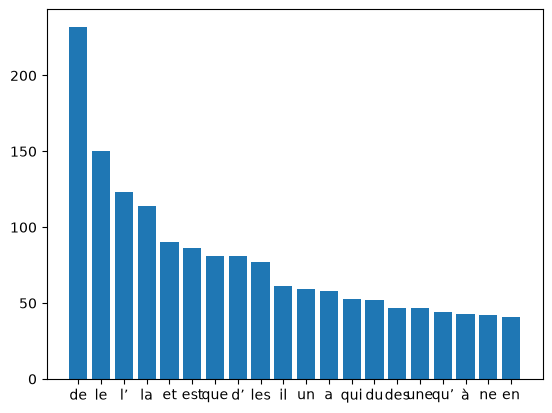

In [25]:
from collections import Counter
import matplotlib.pyplot as plt

words = [
    token.text
    for token in zola_doc
    if not token.is_punct and not token.is_space
]

donnees = Counter(words).most_common(20)

# Extract labels and values from tuples
etiquettes = [x[0] for x in donnees]
valeurs = [x[1] for x in donnees]

# x
indices = range(len(donnees))

# Draw histogram
plt.bar(indices, valeurs)

# Add labels
plt.xticks(indices, etiquettes)

# Display
plt.show()

It doesn't tell us much... 'de' is the most frequent word in the French language and frequency distribution conforms to the [Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law).  
That's why we need stopwords!


In [26]:
words = [
    token.text
    for token in zola_doc
    if not token.is_stop and not token.is_punct and not token.is_space
]

print(Counter(words).most_common(20))

[('général', 29), ('crime', 27), ('Dreyfus', 26), ('guerre', 24), ('vérité', 18), ('commandant', 16), ('affaire', 15), ('colonel', 15), ('état', 15), ('major', 15), ('justice', 14), ('conseil', 13), ('Esterhazy', 13), ('été', 12), ('Paty', 12), ('Clam', 12), ('faire', 11), ('lieutenant', 11), ('homme', 10), ('Gonse', 10)]


It's easy to see what we're talking about, and a historian would no doubt identify the text from this list alone.  But conjugation and plural further truncate the results. We need to lemmatize.

## Lemmatization

Lemmatization is the process of reducing inflected forms of a word. This reduced form (or root word = a dictionary entry), is called a lemma.

For example, loves, loved and loving are all forms of 'love' lemma. The inflection of a word allows you to express different grammatical categories, like tense (loved vs love), number (lover vs lovers), and so on. Lemmatization is necessary because it helps you reduce the inflected forms of a word so that they can be analyzed as a single item. It can also help you normalize the text.

spaCy puts a `lemma_ attribute` on the Token class. This attribute has the lemmatized form of the token:

In [27]:
for token in zola_doc[36:150]:
    if str(token) != str(token.lemma_):
        print(f"{str(token):>20} : {str(token.lemma_)}")

            heureuse : heureux
                 est : être
             menacée : menacer
                  la : le
            honteuse : honteux
                  la : le
                 des : de
              taches : tache
                Vous : vous
                êtes : être
               sorti : sortir
                 des : un
              basses : bas
           calomnies : calomnie
                avez : avoir
             conquis : conquérir
                 les : le
               cœurs : cœur
                Vous : vous
         apparaissez : apparaître
               cette : ce
                   a : avoir
                 été : être
                  la : le
            préparez : préparer
          Exposition : exposition
         universelle : universel
          couronnera : couronner
                Mais : mais
              quelle : quel
              allais : aller
               cette : ce
                  Un : un


**Let's do our sums.**

[Counter](https://docs.python.org/3/library/collections.html#collections.Counter) is a subclass of dict that's specially designed for counting hashable objects in Python. It's a dictionary that stores objects as keys and counts as values.

Just pass to the Counter the list of words to count, and then call the [.most_common()](https://docs.python.org/3/library/collections.html#collections.Counter.most_common) method and that's it!

In [28]:
words = [
    token.lemma_
    for token in zola_doc
    if not token.is_stop and not token.is_punct and not token.is_space
]

print(Counter(words).most_common(20))

[('général', 32), ('crime', 28), ('Dreyfus', 26), ('guerre', 24), ('être', 20), ('vouloir', 20), ('vérité', 18), ('faire', 17), ('commandant', 16), ('état', 16), ('affaire', 15), ('colonel', 15), ('major', 15), ('conseil', 14), ('justice', 14), ('Esterhazy', 13), ('devoir', 12), ('coupable', 12), ('paty', 12), ('accuser', 12)]


Note, for example, that all conjugations of "vouloir" are reduced to its lemma. If you don't lemmatize the text, 'veux' and 'voulais' will be counted as different words, even though they both refer to the same concept. By lemmatizing, you can avoid duplicate words that may overlap conceptually.

This model for French isn't incredible: the counts would make more sense if the lemmatization were better. But still, it's a useful first indication of the topics addressed by the text: we understand that it's about Dreyfus, justice and truth.

With lemmatization, we can usually also recover morphosyntactic labels, which allow us to filter counts according to word (grammatical) category. For instance, what is the most frequent common noun?

## Part-of-Speech Tagging

Part-of-speech (POS) tagging is the process of assigning a POS tag to each token depending on its usage in the sentence. POS tags are useful for assigning a syntactic category like noun or verb to each word.

In spaCy, POS tags are available as an attribute (`pos_`) on the Token object:

In [29]:
print(
    f"{'text':15}"
    f"{'lemma':15}"
    f"{'pos':10}"
    f"{'pos_explanation':10}"
)

for token in zola_doc[:20]:
    if not token.is_space:
        print(
            f"{str(token.text):15}"
            f"{str(token.lemma_):15}"
            f"{str(token.pos_):10}"
            f"{str(spacy.explain(token.pos_)):10}"
        )

text           lemma          pos       pos_explanation
Monsieur       Monsieur       NOUN      noun      
le             le             DET       determiner
Président      président      NOUN      noun      
,              ,              PUNCT     punctuation
Me             me             NOUN      noun      
permettez      permettre      VERB      verb      
-vous          vous           PRON      pronoun   
,              ,              PUNCT     punctuation
dans           dans           ADP       adposition
ma             mon            DET       determiner
gratitude      gratitude      NOUN      noun      
pour           pour           ADP       adposition
le             le             DET       determiner
bienveillant   bienveillant   ADJ       adjective 
accueil        accueil        NOUN      noun      
que            que            PRON      pronoun   
vous           vous           PRON      pronoun   
m’             m’             PRON      pronoun   
avez           avoir    

In [30]:
nouns = [
    token.lemma_
    for token in zola_doc
    if token.pos_ == "NOUN"
]
print(Counter(nouns).most_common(20))

[('-', 32), ('général', 31), ('crime', 28), ('guerre', 24), ('vérité', 18), ('commandant', 16), ('état', 16), ('affaire', 15), ('colonel', 15), ('major', 15), ('conseil', 14), ('justice', 14), ('paty', 12), ('homme', 11), ('lieutenant', 11), ('jour', 9), ('bordereau', 9), ('pièce', 9), ('bureau', 9), ('enquête', 8)]


Not bad. But let's try to format our output better, by storing the counts in a dataframe that we can easily manipulate later:

In [31]:
import pandas as pd
nouns_tally = Counter(nouns)
nouns_df = pd.DataFrame(nouns_tally.most_common(), columns=['nouns', 'count'])
nouns_df.iloc[0:20]

,nouns,count
0,-,32
1,général,31
2,crime,28
3,guerre,24
4,vérité,18
5,commandant,16
6,état,16
7,affaire,15
8,colonel,15
9,major,15


Note that [displacy](https://spacy.io/usage/visualizers) makes it easy to build diagrams, which can look very serious in your thesis or article... 🙄

For instance the dependency visualizer, [dep](https://spacy.io/usage/visualizers#dep), shows part-of-speech tags and syntactic dependencies:

In [32]:
from spacy import displacy

In [33]:
# displaCy options : https://spacy.io/api/top-level#displacy_options

s=20 # a counter to select a sentence (here the 20th)
i=0
for sentence in zola_doc.sents:
    if i==s:
        displacy.render(
            sentence,
            style="dep",
            jupyter=True,
            options={'distance': 100, 'compact':False}
        )
    elif i>s:
        break
    i+=1

## Named-Entity Recognition

We've seen that counting common nouns is a good indicator of the topics. What if we could count the people or places mentioned?

Named-entity recognition (NER) is the process of locating named entities and then classifying them into predefined categories, such as person names, locations, organizations.

Let's see if the NER helps us to better understand the meaning of our text.  
spaCy has the property `.ents` on Doc objects. You can use it to extract named entities:

In [34]:
for ent in zola_doc[2100:2200].ents:
    print(
        f"""
        {ent.text = }
        {ent.label_ = }
        type = {spacy.explain(ent.label_)}"""
    )


        ent.text = 'Paty de Clam'
        ent.label_ = 'PER'
        type = Named person or family.

        ent.text = 'Esterhazy'
        ent.label_ = 'PER'
        type = Named person or family.

        ent.text = 'Dreyfus'
        ent.label_ = 'MISC'
        type = Miscellaneous entities, e.g. events, nationalities, products or works of art

        ent.text = 'M. Scheurer-Kestner'
        ent.label_ = 'PER'
        type = Named person or family.


In the above example, `ent` is a [Span object](https://spacy.io/api/span) with various attributes:

- `.text` gives the Unicode text representation (the string) of the entity.
- `.label_` gives the label of the entity.
- `.start_char` denotes the character offset for the start of the entity.
- `.end_char` denotes the character offset for the end of the entity.

`spacy.explain()` gives descriptive details about each entity label.

Counting people: for a better understanding, we propose 2 methods:

- The first with a `for` loop, to understand how to read the list of entities.
- La seconde (List comprehension) is more pythonic.

In [35]:
# method 1:
people = []
for named_entity in zola_doc.ents:
    if named_entity.label_ == "PER":
        people.append(named_entity.text)

print(Counter(people).most_common(10))

[('Esterhazy', 13), ('Paty de Clam', 12), ('général Billot', 9), ('Boisdeffre', 8), ('général Gonse', 7), ('Président', 6), ('général Mercier', 4), ('M. Scheurer-Kestner', 4), ('Gonse', 3), ('Sandherr', 2)]


In [36]:
# method 2 (pythonic):
people = [
    entity.text
    for entity in zola_doc.ents
    if entity.label_ == 'PER'
]
people_df = pd.DataFrame(Counter(people).most_common(20), columns=['character', 'count'])
people_df.iloc[0:10]

,character,count
0,Esterhazy,13
1,Paty de Clam,12
2,général Billot,9
3,Boisdeffre,8
4,général Gonse,7
5,Président,6
6,général Mercier,4
7,M. Scheurer-Kestner,4
8,Gonse,3
9,Sandherr,2


 You can also use displaCy to visualize these entities. Here, we're only visualizing a few sentences (`list(zola_doc.sents)[116:120]`), but it is of course possible to annotate the entire text (`zola_doc`).

In [37]:
from spacy import displacy
displacy.render(list(zola_doc.sents)[116:120], style='ent', jupyter=True)

/home/lconte/.pyenv/versions/3.12.1/envs/scraping/lib/python3.12/site-packages/spacy/displacy/__init__.py:214: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


## Named-Entity Linking

Named-entity recognition is very useful. It enables us to get entities. But we can't identify them. We know that a person is named 'Picquart', but how do we know who he is? How do we resolve the inevitable ambiguities? -Namesakes are common…

This is the purpose of linking: to try to assign a shared identifier to the entity (e.g. Wikidata). So we learn that 'Picquart' is 'Marie-Georges Picquart (1854-1914)', a key player in the Dreyfus affair. Thanks to this linkage, we can also automatically retrieve information about the person, via APIs!

Entity Linking is a difficult task, and there are many different strategies. We present here [spaCy fishing](https://github.com/Lucaterre/spacyfishing), a spaCy wrapper for entity-fishing, a tool for named entity recognition, linking and disambiguation against Wikidata.

In [38]:
#!pip install spacyfishing

### French

In [39]:
nlp_fr = spacy.load("fr_core_news_md")

In [40]:
import spacyfishing

In [41]:
# default (but the service is often down...)
# nlp_fr.add_pipe("entityfishing", config={'language':'fr'})

In [42]:
# same, using huma-num instance:

nlp_fr.add_pipe("entityfishing", config={
    'language':'fr',
    'api_ef_base': 'http://nerd.huma-num.fr/nerd/service'
})


In [43]:
print(nlp_fr.pipe_names)

['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'entityfishing']


In [44]:
# import text
import pathlib
file_path = '../data/zola_accuse_fr.txt'
zola_doc_fr = nlp_fr(pathlib.Path(file_path).read_text(encoding="utf-8"))

In [45]:
# check service
zola_doc_fr._.metadata

{'disambiguation_text_service': {'status_code': 200,
  'reason': 'OK',
  'ok': True,
  'encoding': 'utf-8'},
 'disambiguation_terms_service': {'status_code': 200,
  'reason': 'OK',
  'ok': True,
  'encoding': 'utf-8'}}

In [46]:
for ent in zola_doc_fr.ents:
    print((ent.text, ent.label_, ent._.kb_qid, ent._.url_wikidata, ent._.nerd_score))

('la France', 'LOC', 'Q142', 'https://www.wikidata.org/wiki/Q142', 0.1307)
('triomphe de notre Exposition universelle', 'MISC', None, None, None)
('Esterhazy', 'PER', 'Q991474', 'https://www.wikidata.org/wiki/Q991474', 0.2118)
('la France', 'LOC', 'Q142', 'https://www.wikidata.org/wiki/Q142', 0.1286)
('Président', 'PER', 'Q30461', 'https://www.wikidata.org/wiki/Q30461', 0.0802)
('Dreyfus', 'MISC', 'Q173457', 'https://www.wikidata.org/wiki/Q173457', 0.2962)
('Un homme néfaste', 'MISC', None, None, None)
('Paty de Clam', 'PER', 'Q532404', 'https://www.wikidata.org/wiki/Q532404', 0.4216)
('l’affaire Dreyfus', 'MISC', 'Q173457', 'https://www.wikidata.org/wiki/Q173457', 0.3765)
('Dreyfus', 'MISC', 'Q173457', 'https://www.wikidata.org/wiki/Q173457', 0.2917)
('Forzinetti', 'MISC', 'Q18744735', 'https://www.wikidata.org/wiki/Q18744735', 0.4444)
('Paty de Clam', 'PER', 'Q532404', 'https://www.wikidata.org/wiki/Q532404', 0.4216)
('l’affaire Dreyfus', 'MISC', 'Q173457', 'https://www.wikidata.org/

spaCy fishing allows you to link several knowledge bases, [collecting information from Wikidata](https://github.com/Lucaterre/spacyfishing#get-extra-information-from-wikidata):

In [47]:
nlp_fr = spacy.load("fr_core_news_md")
nlp_fr.add_pipe("entityfishing", config={
    'language':'fr',
    'extra_info': True
})
for ent in zola_doc_fr.ents:
    if ent.label_ == 'PER':
        print((ent.text, ent.label_, ent._.kb_qid, ent._.url_wikidata, ent._.nerd_score, ent._.other_ids))

('Esterhazy', 'PER', 'Q991474', 'https://www.wikidata.org/wiki/Q991474', 0.2118, None)
('Président', 'PER', 'Q30461', 'https://www.wikidata.org/wiki/Q30461', 0.0802, None)
('Paty de Clam', 'PER', 'Q532404', 'https://www.wikidata.org/wiki/Q532404', 0.4216, None)
('Paty de Clam', 'PER', 'Q532404', 'https://www.wikidata.org/wiki/Q532404', 0.4216, None)
('Sandherr', 'PER', 'Q3174542', 'https://www.wikidata.org/wiki/Q3174542', 0.4215, None)
('Paty de Clam', 'PER', 'Q532404', 'https://www.wikidata.org/wiki/Q532404', 0.4163, None)
('général Mercier', 'PER', 'Q3022830', 'https://www.wikidata.org/wiki/Q3022830', 0.7288, None)
('Boisdeffre', 'PER', 'Q1887774', 'https://www.wikidata.org/wiki/Q1887774', 0.2594, None)
('général Gonse', 'PER', 'Q1063595', 'https://www.wikidata.org/wiki/Q1063595', 0.9362, None)
('Paty de Clam', 'PER', 'Q532404', 'https://www.wikidata.org/wiki/Q532404', 0.4163, None)
('Paty de Clam', 'PER', 'Q532404', 'https://www.wikidata.org/wiki/Q532404', 0.416, None)
('madame Drey

At last but not at least, you can display the result in a very convenient way:

In [48]:
options = {
    "ents": ["MISC", "LOC", "PER"],
    "colors": {"LOC": "#82e0aa", "PER": "#85c1e9", "MISC": "#f0b27a"}
}

params = {
    "text": zola_doc_fr.text,
    "ents": [
        {
            "start": ent.start_char,
            "end": ent.end_char,
            "label": ent.label_,
            "kb_id": ent._.kb_qid,
            "kb_url": ent._.url_wikidata
        }
        for ent in zola_doc_fr.ents
    ],
    "title": None
}

spacy.displacy.render(params, style="ent", manual=True, options=options, jupyter=True)

### English

In [49]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 7.0 MB/s eta 0:00:00m eta 0:00:010:00:01m

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [50]:
nlp_en = spacy.load("en_core_web_md")

In [51]:
nlp_en.add_pipe("entityfishing", config={
    'language':'en',
    'api_ef_base': 'http://nerd.huma-num.fr/nerd/service'
})

In [52]:
import pathlib
file_path = '../data/zola_accuse_en.txt'
zola_doc_en = nlp_en(pathlib.Path(file_path).read_text(encoding="utf-8"))

In [53]:
for ent in zola_doc_en.ents:
    if ent.label_ == 'PERSON':
        print((ent.text, ent.label_, ent._.kb_qid, ent._.url_wikidata, ent._.nerd_score))

('Dreyfus', 'PERSON', 'Q3039429', 'https://www.wikidata.org/wiki/Q3039429', 0.4062)
('Dreyfus', 'PERSON', 'Q171826', 'https://www.wikidata.org/wiki/Q171826', 0.5699)
('Du Paty de Clam', 'PERSON', 'Q532404', 'https://www.wikidata.org/wiki/Q532404', 0.8408)
('Dreyfus', 'PERSON', 'Q171826', 'https://www.wikidata.org/wiki/Q171826', 0.5699)
('Dreyfus', 'PERSON', 'Q171826', 'https://www.wikidata.org/wiki/Q171826', 0.5699)
('Du Paty de Clam', 'PERSON', 'Q532404', 'https://www.wikidata.org/wiki/Q532404', 0.8408)
('Dreyfus', 'PERSON', 'Q171826', 'https://www.wikidata.org/wiki/Q171826', 0.5699)
('Colonel Sandherr', 'PERSON', 'Q3174542', 'https://www.wikidata.org/wiki/Q3174542', 0.8284)
('Paty de Clam', 'PERSON', None, None, None)
('Dreyfus', 'PERSON', 'Q5307362', 'https://www.wikidata.org/wiki/Q5307362', 0.5696)
('Dreyfus', 'PERSON', 'Q5307362', 'https://www.wikidata.org/wiki/Q5307362', 0.5696)
('Mercier', 'PERSON', 'Q3306378', 'https://www.wikidata.org/wiki/Q3306378', 0.479)
('De Boisdeffre', '

## Preprocessing Functions

To bring your text into a format ideal for analysis, you can write preprocessing functions to encapsulate your cleaning process. For example, in this section, you’ll create a preprocessor that applies the following operations:

- Lowercases the text
- Lemmatizes each token
- Removes punctuation symbols
- Removes stop words

A preprocessing function converts text to an analyzable format. It’s typical for most NLP tasks.

In [54]:
# Preprocessing
def preprocess_lemma(token):
    return token.lemma_.strip().lower()

# Filter: a function that returns True or False for a token according to certain criteria
def is_token_allowed(token):
    return bool(
        token
        and str(token).strip()
        and not token.is_stop
        and not token.is_punct
    )

filtered_zola_lemmas = [
    preprocess_lemma(token)
    for token in zola_doc
    if is_token_allowed(token)
]

print(filtered_zola_lemmas)

['monsieur', 'président', 'permettre', 'vous', 'gratitude', 'bienveillant', 'accueil', 'avoir', 'jour', 'souci', 'gloire', 'étoile', 'heureux', 'jusqu’', 'ici', 'menacer', 'honteux', 'ineffaçable', 'tache', 'être', 'sortir', 'sain', 'bas', 'calomnie', 'avoir', 'conquérir', 'cœur', 'apparaître', 'rayonnant', 'apothéose', 'fête', 'patriotique', 'alliance', 'russe', 'être', 'france', 'préparer', 'présider', 'solennel', 'triomphe', 'exposition', 'universel', 'couronner', 'grand', 'siècle', 'travail', 'vérité', 'liberté', 'tache', 'boue', 'nom', 'aller', 'règne', 'abominable', 'affaire', 'dreyfus', 'conseil', 'guerre', 'venir', 'ordre', 'oser', 'acquitter', 'esterhazy', 'soufflet', 'suprême', 'vérité', 'justice', 'finir', 'france', 'joue', 'souillure', 'histoire', 'écrire', 'présidence', 'crime', 'social', 'commettre', 'puisqu’', 'oser', 'oser', 'vérité', 'dire', 'promettre', 'justice', 'régulièrement', 'saisir', 'faire', 'plein', 'entier', 'devoir', 'vouloir', 'complice', 'nuit', 'hanter',

In [55]:
print(
    f"{'text':15}"
    f"{'is_allowed':15}"
)

for token in zola_doc[:10]:
    print(
        f"{str(token.text):15}"
        f"{str(is_token_allowed(token)):15}"
    )

text           is_allowed     
Monsieur       True           
le             False          
Président      True           
,              False          

              False          
Me             False          
permettez      True           
-vous          True           
,              False          
dans           False          


## Appendix. Import

In [56]:
# all imports
'''
import spacy
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from spacy import displacy
import fr_core_news_md
import pandas as pd
import pathlib
from collections import Counter
'''

'\nimport spacy\nfrom spacy.lang.fr.stop_words import STOP_WORDS as fr_stop\nfrom spacy import displacy\nimport fr_core_news_md\nimport pandas as pd\nimport pathlib\nfrom collections import Counter\n'

In [57]:
#https://conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html#sharing-an-environment
#!conda env export

/bin/bash: ligne 1: conda : commande introuvable
